# SBERT 

In [2]:
# SBERT k-NN 
import os 
import torch
from sentence_transformers import SentenceTransformer
from transformers import BertTokenizer, BertModel
from scipy.spatial.distance import cosine
import json
import re
import psycopg2
import psycopg2.extras
import numpy as np
from collections import Counter
import wordninja
import joblib
from pathlib import Path
import cv2
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity
from scipy.sparse import hstack
from sklearn.preprocessing import normalize
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
import umap
from tqdm import tqdm
import matplotlib.cm as cm
import matplotlib.patches as mpatches
from sklearn.preprocessing import LabelEncoder
import matplotlib.colors as mcolors
import distinctipy
import math
import pandas as pd
import seaborn as sns

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(torch.__version__)
print(device)


2.5.1+cu121
cuda


In [28]:
dataset_path = Path(r'C:\Users\danie\Desktop\_\Daniela_Curmi\University\Final_Year_Project\Code_Implementation\Website')

In [29]:
# Database connection
def get_db_connection():
    conn = psycopg2.connect(
        host="localhost",
        database="ART_RECSYS_DB_LOCAL",
        user="postgres",
        password="Catmelon304!"
    )
    return conn

print(get_db_connection())

<connection object at 0x0000019B2BA109D0; dsn: 'user=postgres password=xxx dbname=ART_RECSYS_DB_LOCAL host=localhost', closed: 0>


## Preprocessing 

### Validation and Cleaning

Validation has already been performed in the  TF-IDF VSM notebook, hence it's possible to move directly to the NULL handling section of this pipeline.

### Handle NULLs/missing values and Text Normalisation

As discussed earlier, the following fields contain missing/null values (see histogram plot of missing values per field) and for the recommendation architecture I will be using a larger set of text field since SBERT is a transformer-based architecture, which means that model adopts the mechanism of attention, weighing the influence of different parts of the input data. 

Fields that contain missing values; 

**Painting Details** title, year_created, genre, media, description_tags

**Artist Details** nationality, feilds, art_movements, bio

Using explicit NULL tokens e.g. [GENRE] unknown genre, will allow the model to learn the lack of certain fields within a painting representation.

*N.B: The only fields that are not handled for missing values are artist and art_style because they have no missing/null values.* 

- handle missing values
- denote fields
- clean noisy data
- deduplicate tokens
- normalise structured metadata
- convert numbers to semantic representation

Raw text can't be used to extract embeddings, since the data is heterogeneous and raw concatenation has no field boundaries, and is partially structured containing missing data. 

#### Free Text 
**Title, Bio**

In [18]:
# Title preprocessing i.e. NULL/missing handling and text normalisation 
ROMAN_NUMERAL_PATTERN = re.compile(r'\b(i{1,3}|iv|v|vi{0,3}|ix|x)\b', re.IGNORECASE)

def normalise_roman_numerals(text: str) -> str:
    return ROMAN_NUMERAL_PATTERN.sub(lambda m: m.group(0).upper(), text)

def process_title(title: str) -> str:
    # Handle NULL/missing values 
    if title is None or title.strip() == "":
        return "unknown title"

    # Normalise whitespace
    title = title.strip() 
    title = re.sub(r'\s+', ' ', title)

    # Fix broken apostrophes e.g. "Martin S" to "Martin's" and normalise roman numerals
    title = re.sub(r"\b([A-Za-z]+)\s+S\b", r"\1's", title)
    title = normalise_roman_numerals(title)

    # Remove trailing index numbers only when safe
    if re.search(r'(untitled|drawing|study|composition|abstraction)', title, re.IGNORECASE):
        title = re.sub(r'\s*\(?\d+\)?$', '', title)

    title = re.sub(r'\s+', ' ', title).strip()

    return title

# Used to avoid cutting mid-word
def safe_cut(text, length):
    cut = text[:length]
    return cut[:cut.rfind(" ")] if " " in cut else cut

# Bio preprocessing, including cutoff since bio fields contain the most 
# characters and heavily bias the embedding space if left untrimmed
def process_bio(bio: str, max_chars=2000) -> str:
    if bio is None or bio.strip() == "":
        return "no biography available"
    
    # Normalise whitespace, including newlines and tabs
    bio = bio.strip()
    bio = re.sub(r'\s+', ' ', bio)

    # Truncate so that bio is token-safe for SBERT 
    if len(bio) > max_chars:
        head_len = int(max_chars * 0.6)
        tail_len = max_chars - head_len

        head = safe_cut(bio, head_len)
        tail = safe_cut(bio[::-1], tail_len)[::-1]

        bio = f"{head} ... {tail}"

    return bio


#### Categorical 
**Artist, Genre, Art Style, Nationality**


In [19]:
# This method can be used for all categorical fields, to handle NULL/missing values, convert all fields to lowercase apart 
# from artist and remove excess whitespace 
def process_categorical_field(field_value: str, field_name: str = None) -> str:
    # Handle NULL/missing values 
    if field_value is None or field_value.strip() == "":
        return f"unknown {field_name}"

    field_value = field_value.strip()

    # Normalise whitespace and convert all categoricals to lowercase except artist since it harms entity recognition
    field_value = re.sub(r'\s+', ' ', field_value)
    if field_name != "artist":
        field_value = field_value.lower()

    return field_value

#### Multi-Value Fields
**Description Tags, Media, Art Movements, Fields**


In [20]:
# This method can be used for all multi-value fields, it handles nulls/missing values, 
# converts all comma seperated items to lower case, and applies the respective preprocessing for description_tags, 
# joining all value segments using |
def process_multi_value_field(feild_value: str, field_name: str = None) -> str:
    # Handle NULL/missing values
    if feild_value is None or feild_value.strip() == "":
        return f"unknown {field_name}" 

    # Split on comma 
    items = feild_value.split(",")
    cleaned = []
    for item in items:
        item = item.strip().lower()
        if item == "":
            continue
        
        # Replace hyphens with space when in-between words only and normalise internal whitespace
        if field_name == "description tags":
            item = re.sub(r'(?<=\w)-(?=\w)', ' ', item)

            # Apply segmentation only if; no spaces already, long enough, purely alphabetic
            if " " not in item and len(item) > 10 and item.isalpha():
                split_words = wordninja.split(item)

                # Safety checks to avoid bad splits (e.g. single char fragments)
                if (len(split_words) > 1 and all(len(w) > 2 for w in split_words) and len(" ".join(split_words)) >= len(item) * 0.8):
                    item = " ".join(split_words) 

        item = re.sub(r'\s+', ' ', item)
        cleaned.append(item)

    if not cleaned:
        return f"unknown {field_name}" 

    # Deduplicate while preserving order
    unique_items = list(dict.fromkeys(cleaned))

    return " | ".join(unique_items)

#### Numerical Features
**Year Created**

In [21]:
# Instead of using years, encode them as semantic 
def process_year(year_created):
    # NULL/missing 
    if year_created is None or str(year_created).strip() == "":
        return "unknown period"

    try:
        year = int(year_created)
    except (ValueError, TypeError):
        return "unknown period"

    # Period mapping 
    if year < 1400:
        return "medieval period 14th century"
    elif year < 1600:
        return "renaissance period 16th century"
    elif year < 1700:
        return "baroque period 17th century"
    elif year < 1800:
        return "rococo enlightenment period 18th century"
    elif year <= 1850:
        return "early modern period 18th century"
    elif year <= 1900:
        return "late 19th century impressionism era"
    elif year <= 1945:
        return "early 20th century modernism"
    elif year <= 1970:
        return "mid 20th century post war modern"
    elif year <= 2000:
        return "late 20th century contemporary"
    else:
        return "contemporary period 20th century" 

In [22]:
def format_text_fields(title, year_created, genre, art_style, media, description_tags, artist, nationality, fields, art_movements, bio):
    title_processed = process_title(title)
    year_processed = process_year(year_created)
    genre_processed = process_categorical_field(genre, "genre")
    art_style_processed = process_categorical_field(art_style, "art style")
    media_processed = process_multi_value_field(media, "media")
    description_tags_processed = process_multi_value_field(description_tags, "description tags")
    artist_processed = process_categorical_field(artist, "artist")
    nationality_processed = process_categorical_field(nationality, "nationality")
    fields_processed = process_multi_value_field(fields, "fields")
    art_movements_processed = process_multi_value_field(art_movements, "art movements")
    bio_processed = process_bio(bio)

    # Structured reperesntation 
    structured = {
        "title": title_processed,
        "year_period": year_processed,
        "genre": genre_processed,
        "art_style": art_style_processed,
        "media": media_processed.split(" | "),
        "description_tags": description_tags_processed.split(" | "),
        "artist": artist_processed,
        "nationality": nationality_processed,
        "fields": fields_processed.split(" | "),
        "art_movements": art_movements_processed.split(" | "),
        "bio": bio_processed
    }

    return structured

def build_processed_texts():
    conn = get_db_connection()
    cur = conn.cursor()

    query = """
    SELECT painting_id, title, year_created, genre, art_style, media, 
        description_tags, artist, nationality, fields, art_movements, bio
    FROM paintings_and_artists_metadata_bert
    ORDER BY painting_id
    """
    cur.execute(query)
    rows = cur.fetchall()

    processed_data = []
    painting_ids = []
    for row in rows:
        (painting_id, title, year_created, genre, art_style, media, description_tags, 
         artist, nationality, fields, art_movements, bio) = row
        structured = format_text_fields(title, year_created, genre, art_style, media, description_tags, 
                                              artist, nationality, fields, art_movements, bio)
        processed_data.append((json.dumps(structured), painting_id))
        painting_ids.append(painting_id)

    conn.commit()
    cur.close()
    conn.close()

    return processed_data, painting_ids

In [ ]:
processed_data, painting_ids = build_processed_texts() 

# Backup preprocessed fields
joblib.dump(processed_data, "processed_data.pkl")

['processed_data.pkl']

In [16]:
processed_data = joblib.load("processed_data.pkl")

In [ ]:
def store_processed_data(processed_data):
    conn = get_db_connection()
    cur = conn.cursor() 
    
    for item in processed_data:
        structured_json, painting_id = item

        cur.execute("""
            UPDATE paintings_and_artists_metadata_bert
            SET processed_fields = %s
            WHERE painting_id = %s
        """, (
            structured_json,
            painting_id
        ))

    conn.commit()
    cur.close()
    conn.close()

store_processed_data(processed_data)

### Extract Embeddings using SBERT

In [67]:
# Load SBERT model to be used for per-field embedding extraction 
model = SentenceTransformer('all-mpnet-base-v2') # all-roberta-large-v1, paraphrase-multilingual-mpnet-base-v2, all-mpnet-base-v2

def prepare_field_text(value):
    if isinstance(value, list):
        return " | ".join(value) if value else ""
    text = str(value).strip()
    return text

In [ ]:
# Extract embeddings per field for late fusion using weights 
embeddings = []
for item_json, painting_id in processed_data:
    item = json.loads(item_json)  

    item_embeddings = {}

    for field, value in item.items():
        text = prepare_field_text(value)

        if text == "":
            continue

        item_embeddings[field] = model.encode(text, normalize_embeddings=True)

    embeddings.append(item_embeddings)

# Backup embedding storage apart from DB
joblib.dump(embeddings, "SBERT_embeddings_per_field.pkl")

['SBERT_embeddings_per_field.pkl']

In [66]:
embeddings = joblib.load("SBERT_embeddings_per_field_all_mpnet.pkl")

In [ ]:
def to_list(array):
    if array is None:
        return None
    return array.tolist() 

def store_embeddings(embeddings, painting_ids, batch_size=500):
    conn = get_db_connection()
    cur = conn.cursor()

    batch = []

    for idx, item_embeddings in enumerate(embeddings):
        pid = painting_ids[idx]

        batch.append((
            to_list(item_embeddings.get("title")),
            to_list(item_embeddings.get("year_period")),
            to_list(item_embeddings.get("genre")),
            to_list(item_embeddings.get("art_style")),
            to_list(item_embeddings.get("description_tags")),
            to_list(item_embeddings.get("media")),
            to_list(item_embeddings.get("artist")),
            to_list(item_embeddings.get("nationality")),
            to_list(item_embeddings.get("fields")),
            to_list(item_embeddings.get("art_movements")),
            to_list(item_embeddings.get("bio")),
            pid
        ))

        if len(batch) >= batch_size:
            cur.executemany("""
                UPDATE paintings_and_artists_metadata_bert
                SET 
                    title_embedding = %s,
                    year_embedding = %s,
                    genre_embedding = %s,
                    art_style_embedding = %s,
                    description_tags_embedding = %s,
                    media_embedding = %s,
                    artist_embedding = %s,
                    nationality_embedding = %s,
                    fields_embedding = %s,
                    art_movements_embedding = %s,
                    bio_embedding = %s
                WHERE painting_id = %s
            """, batch)

            conn.commit()
            batch.clear()

    if batch:
        cur.executemany(..., batch)
        conn.commit()

    cur.close()
    conn.close()

In [ ]:
store_embeddings(embeddings, painting_ids)

### Build per-field Embedding Matrices

In [68]:
FIELDS = [
    "title", 
    "year_period", 
    "genre", 
    "art_style",
    "description_tags", 
    "media", 
    "artist",
    "nationality", 
    "fields", 
    "art_movements", 
    "bio"
]

def build_embedding_matrices(embeddings):
    embedding_matrices = {}
    for field in FIELDS:
        vectors = []

        all_vecs = [item[field] for item in embeddings if field in item]
        mean_vec = np.mean(all_vecs, axis=0)

        for item in embeddings:
            vec = item.get(field)
            
            if vec is None:
                vec = item.get(field, mean_vec) # fallback, since zero will create 0 similarity score when using cosine similarity
            vectors.append(vec)

        embedding_matrices[field] = np.vstack(vectors)  # shape: (N, 768)
    return embedding_matrices

embedding_matrices = build_embedding_matrices(embeddings)

In [28]:
print(embedding_matrices)

{'title': array([[-0.00107514, -0.07139069,  0.00292242, ..., -0.00744759,
         0.03193166, -0.03442939],
       [-0.01463944,  0.00509586,  0.01639824, ..., -0.00085918,
         0.01304694, -0.02174195],
       [-0.01432553, -0.02987965, -0.0051297 , ..., -0.02024694,
         0.01124819, -0.0239872 ],
       ...,
       [-0.02439257,  0.00367723, -0.01283118, ...,  0.0276729 ,
         0.04638157, -0.0211883 ],
       [ 0.02031488, -0.04543445, -0.02877787, ...,  0.01795572,
        -0.01322378,  0.02816239],
       [-0.01364143, -0.03255045, -0.02543386, ..., -0.00720913,
        -0.03787489,  0.0216038 ]], dtype=float32), 'year_period': array([[-0.03678198, -0.02405479,  0.00835123, ...,  0.05739656,
        -0.02613153,  0.02129002],
       [-0.03678198, -0.02405479,  0.00835123, ...,  0.05739656,
        -0.02613153,  0.02129002],
       [-0.03678198, -0.02405479,  0.00835123, ...,  0.05739656,
        -0.02613153,  0.02129002],
       ...,
       [ 0.00486143, -0.02282704, 

In [80]:
for field, mat in embedding_matrices.items():
    print(field, mat.shape)

title (81444, 768)
year_period (81444, 768)
genre (81444, 768)
art_style (81444, 768)
description_tags (81444, 768)
media (81444, 768)
artist (81444, 768)
nationality (81444, 768)
fields (81444, 768)
art_movements (81444, 768)
bio (81444, 768)


In [14]:
embedding_matrices = joblib.load("SBERT_embedding_matrices.pkl")

#### Test Query Embedding of Painting User Interacted with

In [69]:
# Raw Test Query 
query = {
    "painting_id" : "30081",
    "title": "The Seine At Bougival In The Evening",
    "year_created": "",
    "description_tags": "Sky,Tree,Bank",
    "media": "",
    "genre": "landscape",
    "art_style": "Impressionism",
    "artist": "Claude Monet",
    "art_movements": "Impressionism",
    "fields": "painting",
    "nationality": "French",
    "bio": "Oscar-Claude Monet (/moʊˈneɪ/; French: [klod mɔnɛ]; 14 November 1840 – 5 December 1926) was a founder of French Impressionist painting, and the most consistent and prolific practitioner of the movement's philosophy of expressing one's perceptions before nature, especially as applied to plein air landscape painting. The term Impressionism is derived from the title of his painting Impression, soleil levant (Impression, Sunrise), which was exhibited in 1874 in the first of the independent exhibitions mounted by Monet and his associates as an alternative to the Salon de Paris. Monet's ambition of documenting the French countryside led him to adopt a method of painting the same scene many times in order to capture the changing of light and the passing of the seasons. From 1883 Monet lived in Giverny, where he purchased a house and property and began a vast landscaping project which included lily ponds that would become the subjects of his best-known works. In 1899 he began painting the water lilies, first in vertical views with a Japanese bridge as a central feature, and later in the series of large-scale paintings that was to occupy him continuously for the next 20 years of his life. Claude Monet was born on 14 November 1840 on the fifth floor of 45 rue Laffitte, in the 9th arrondissement of Paris. He was the second son of Claude Adolphe Monet and Louise Justine Aubrée Monet, both of them second-generation Parisians. On 20 May 1841, he was baptized in the local parish church, Notre-Dame-de-Lorette, as Oscar-Claude, but his parents called him simply Oscar. (He signed his juvenilia O. Monet.) Despite being baptized Catholic, Monet later became an atheist. In 1845, his family moved to Le Havre in Normandy. His father wanted him to go into the family's ship-chandling and grocery business, but Monet wanted to become an artist. His mother was a singer, and supported Monet's desire for a career in art. On 1 April 1851, Monet entered Le Havre secondary school of the arts. Locals knew him well for his charcoal caricatures, which he would sell for ten to twenty francs. Monet also undertook his first drawing lessons from Jacques-François Ochard, a former student of Jacques-Louis David. On the beaches of Normandy around 1856 he met fellow artist Eugène Boudin, who became his mentor and taught him to use oil paints. Boudin taught Monet 'en plein air' (outdoor) techniques for painting. Both received the influence of Johan Barthold Jongkind. On 28 January 1857, his mother died. At the age of sixteen, he left school and went to live with his widowed, childless aunt, Marie-Jeanne Lecadre. When Monet traveled to Paris to visit the Louvre, he witnessed painters copying from the old masters. Having brought his paints and other tools with him, he would instead go and sit by a window and paint what he saw. Monet was in Paris for several years and met other young painters, including Édouard Manet and others who would become friends and fellow Impressionists. After drawing a low ballot number in March 1861, Monet was drafted into the First Regiment of African Light Cavalry (Chasseurs d'Afrique) in Algeria for a seven-year period of military service. His prosperous father could have purchased Monet's exemption from conscription but declined to do so when his son refused to give up painting. While in Algeria Monet did only a few sketches of casbah scenes, a single landscape, and several portraits of officers, all of which have been lost. In a Le Temps interview of 1900 however he commented that the light and vivid colours of North Africa 'contained the germ of my future researches'. After about a year of garrison duty in Algiers, Monet contracted typhoid fever and briefly went absent without leave. Following convalescence, Monet's aunt intervened to get him out of the army if he agreed to complete a course at an art school. It is possible that the Dutch painter Johan Barthold Jongkind, whom Monet knew, may have prompted his aunt on this matter."
}

query_clean = format_text_fields(query["title"], query["year_created"], query["genre"], query["art_style"], query["media"],
                    query["description_tags"], query["artist"], query["art_movements"], query["fields"], query["nationality"], 
                    query["bio"])
print(query_clean)

def encode_query_sbert(query_structured, model):
    query_embeddings = {}

    for field, value in query_structured.items():
        text = prepare_field_text(value)

        if text == "":
            continue

        query_embeddings[field] = model.encode(text, normalize_embeddings=True)
    return query_embeddings

{'title': 'The Seine At Bougival In The Evening', 'year_period': 'unknown period', 'genre': 'landscape', 'art_style': 'impressionism', 'media': ['unknown media'], 'description_tags': ['sky', 'tree', 'bank'], 'artist': 'Claude Monet', 'nationality': 'impressionism', 'fields': ['painting'], 'art_movements': ['french'], 'bio': "Oscar-Claude Monet (/moʊˈneɪ/; French: [klod mɔnɛ]; 14 November 1840 – 5 December 1926) was a founder of French Impressionist painting, and the most consistent and prolific practitioner of the movement's philosophy of expressing one's perceptions before nature, especially as applied to plein air landscape painting. The term Impressionism is derived from the title of his painting Impression, soleil levant (Impression, Sunrise), which was exhibited in 1874 in the first of the independent exhibitions mounted by Monet and his associates as an alternative to the Salon de Paris. Monet's ambition of documenting the French countryside led him to adopt a method of painting 

In [70]:
WEIGHTS = {
    "title": 0.1,
    "genre": 0.1,
    "art_style": 0.2,
    "description_tags": 0.1,
    "media": 0.05,
    "year_period": 0.05,
    "artist": 0.05,
    "nationality": 0.03,
    "fields": 0.03,
    "art_movements": 0.1,
    "bio": 0.03   
}

def normalise_weights(weights):
    total = sum(weights.values())
    return {k: v / total for k, v in weights.items()}

WEIGHTS = normalise_weights(WEIGHTS)

def compute_similarity_per_field_sbert(query_embeddings, embedding_matrices):
    similarities = {}

    for field, matrix in embedding_matrices.items():
        q = query_embeddings.get(field)

        if q is None:
            similarities[field] = np.zeros(matrix.shape[0])
            continue

        sim = matrix @ q   
        similarities[field] = sim

    return similarities

def weighted_late_fusion(similarities, weights):
    final_scores = np.zeros(len(next(iter(similarities.values()))))

    for field, sim in similarities.items():
        final_scores += weights.get(field, 0) * sim

    return final_scores

def get_top_k(final_scores, query_index, k=30):
    final_scores = final_scores.copy()
    final_scores[query_index] = -np.inf
    top_indices = np.argpartition(final_scores, -k)[-k:]
    top_indices = top_indices[np.argsort(final_scores[top_indices])[::-1]]
    return top_indices, final_scores[top_indices]

In [71]:
painting_id_to_index = {
    pid: idx for idx, (_, pid) in enumerate(processed_data)
}
def recommend_sbert(query_structured, model, embedding_matrices, weights, painting_id_to_index, query_id, k=10):
    query_embeddings = encode_query_sbert(query_structured, model)
    similarities = compute_similarity_per_field_sbert(query_embeddings, embedding_matrices)
    final_scores = weighted_late_fusion(similarities, weights)
    query_index = painting_id_to_index[int(query_id)]
    top_indices, scores = get_top_k(final_scores, query_index, k)
    return top_indices, scores, similarities

top_indices, scores, similarities = recommend_sbert(query_clean, model, embedding_matrices, WEIGHTS, painting_id_to_index, query["painting_id"])

def fetch_paintings(painting_ids):
    conn = get_db_connection()
    cur = conn.cursor(cursor_factory=psycopg2.extras.RealDictCursor)

    # Preserve order 
    cur.execute("""
        SELECT 
            painting_id,
            title,
            year_created,
            artist,
            genre, 
            art_style,
            media,
            description_tags,
            nationality,
            fields, 
            art_movements,
            bio,
            image_path
        FROM paintings_and_artists_metadata_bert
        WHERE painting_id = ANY(%s)
        ORDER BY array_position(%s, painting_id);
    """, (painting_ids, painting_ids))

    rows = cur.fetchall()

    cur.close()
    conn.close()

    return rows

query_embeddings = encode_query_sbert(query_clean, model)
query_id = query["painting_id"]
query_index = painting_id_to_index[int(query_id)]
print(np.allclose(embedding_matrices["title"][query_index], query_embeddings["title"]))

True


1. Painting ID: 30102, Score: 0.8567
   Title: The Seine Near Argenteuil
   Artist: Claude Monet
   Year Created: None
   Genre: landscape
   Art Style: Impressionism
   Media: None
   Description Tags: Sky,Grassfamily
   Fields: painting
   Art Movements: Impressionism
   Nationality: French
   Bio: Oscar-Claude Monet (/moʊˈneɪ/; French: [klod mɔnɛ]; 14 November 1840 – 5 December 1926) was a founder of French Impressionist painting, and the most consistent and prolific practitioner of the movement's philosophy of expressing one's perceptions before nature, especially as applied to plein air landscape painting. The term "Impressionism" is derived from the title of his painting Impression, soleil levant (Impression, Sunrise), which was exhibited in 1874 in the first of the independent exhibitions mounted by Monet and his associates as an alternative to the Salon de Paris.
 Monet's ambition of documenting the French countryside led him to adopt a method of painting the same scene many ti

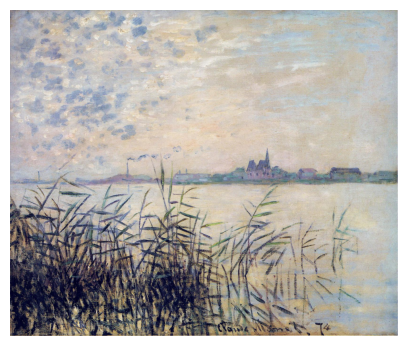

2. Painting ID: 29315, Score: 0.8532
   Title: Evening At Argenteuil
   Artist: Claude Monet
   Year Created: None
   Genre: landscape
   Art Style: Impressionism
   Media: None
   Description Tags: Atmosphericphenomenon,Tree,Sky
   Fields: painting
   Art Movements: Impressionism
   Nationality: French
   Bio: Oscar-Claude Monet (/moʊˈneɪ/; French: [klod mɔnɛ]; 14 November 1840 – 5 December 1926) was a founder of French Impressionist painting, and the most consistent and prolific practitioner of the movement's philosophy of expressing one's perceptions before nature, especially as applied to plein air landscape painting. The term "Impressionism" is derived from the title of his painting Impression, soleil levant (Impression, Sunrise), which was exhibited in 1874 in the first of the independent exhibitions mounted by Monet and his associates as an alternative to the Salon de Paris.
 Monet's ambition of documenting the French countryside led him to adopt a method of painting the same sc

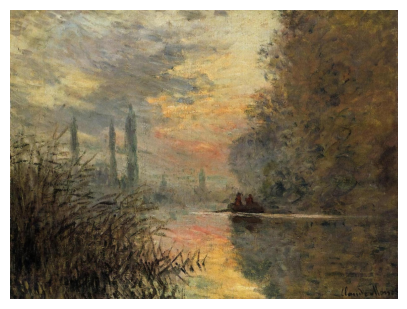

3. Painting ID: 29804, Score: 0.8390
   Title: The Alps Seen From Cap D Antibes
   Artist: Claude Monet
   Year Created: None
   Genre: None
   Art Style: Impressionism
   Media: None
   Description Tags: None
   Fields: painting
   Art Movements: Impressionism
   Nationality: French
   Bio: Oscar-Claude Monet (/moʊˈneɪ/; French: [klod mɔnɛ]; 14 November 1840 – 5 December 1926) was a founder of French Impressionist painting, and the most consistent and prolific practitioner of the movement's philosophy of expressing one's perceptions before nature, especially as applied to plein air landscape painting. The term "Impressionism" is derived from the title of his painting Impression, soleil levant (Impression, Sunrise), which was exhibited in 1874 in the first of the independent exhibitions mounted by Monet and his associates as an alternative to the Salon de Paris.
 Monet's ambition of documenting the French countryside led him to adopt a method of painting the same scene many times in or

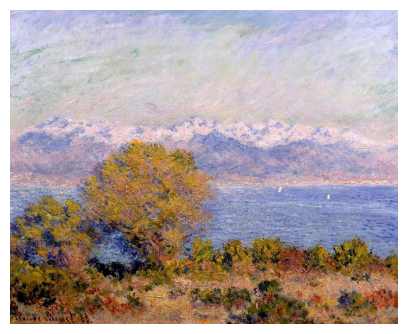

4. Painting ID: 30073, Score: 0.8374
   Title: The Seacoast Of Pourville Low Tide
   Artist: Claude Monet
   Year Created: None
   Genre: None
   Art Style: Impressionism
   Media: None
   Description Tags: None
   Fields: painting
   Art Movements: Impressionism
   Nationality: French
   Bio: Oscar-Claude Monet (/moʊˈneɪ/; French: [klod mɔnɛ]; 14 November 1840 – 5 December 1926) was a founder of French Impressionist painting, and the most consistent and prolific practitioner of the movement's philosophy of expressing one's perceptions before nature, especially as applied to plein air landscape painting. The term "Impressionism" is derived from the title of his painting Impression, soleil levant (Impression, Sunrise), which was exhibited in 1874 in the first of the independent exhibitions mounted by Monet and his associates as an alternative to the Salon de Paris.
 Monet's ambition of documenting the French countryside led him to adopt a method of painting the same scene many times in 

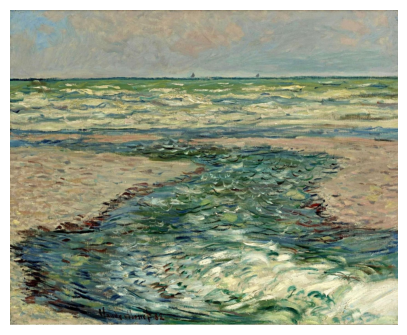

5. Painting ID: 29526, Score: 0.8370
   Title: Morning On The Seine Near Giverny The Fog
   Artist: Claude Monet
   Year Created: None
   Genre: None
   Art Style: Impressionism
   Media: None
   Description Tags: None
   Fields: painting
   Art Movements: Impressionism
   Nationality: French
   Bio: Oscar-Claude Monet (/moʊˈneɪ/; French: [klod mɔnɛ]; 14 November 1840 – 5 December 1926) was a founder of French Impressionist painting, and the most consistent and prolific practitioner of the movement's philosophy of expressing one's perceptions before nature, especially as applied to plein air landscape painting. The term "Impressionism" is derived from the title of his painting Impression, soleil levant (Impression, Sunrise), which was exhibited in 1874 in the first of the independent exhibitions mounted by Monet and his associates as an alternative to the Salon de Paris.
 Monet's ambition of documenting the French countryside led him to adopt a method of painting the same scene many ti

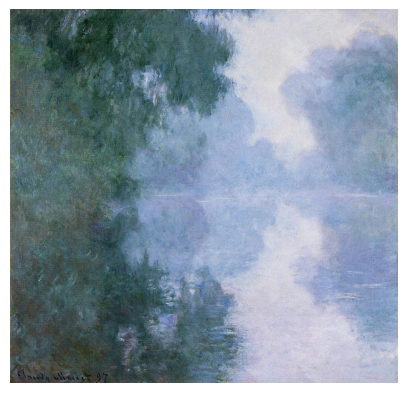

6. Painting ID: 29822, Score: 0.8364
   Title: The Banks Of The Seine Ile De La Grande Jatte
   Artist: Claude Monet
   Year Created: None
   Genre: None
   Art Style: Impressionism
   Media: None
   Description Tags: None
   Fields: painting
   Art Movements: Impressionism
   Nationality: French
   Bio: Oscar-Claude Monet (/moʊˈneɪ/; French: [klod mɔnɛ]; 14 November 1840 – 5 December 1926) was a founder of French Impressionist painting, and the most consistent and prolific practitioner of the movement's philosophy of expressing one's perceptions before nature, especially as applied to plein air landscape painting. The term "Impressionism" is derived from the title of his painting Impression, soleil levant (Impression, Sunrise), which was exhibited in 1874 in the first of the independent exhibitions mounted by Monet and his associates as an alternative to the Salon de Paris.
 Monet's ambition of documenting the French countryside led him to adopt a method of painting the same scene man

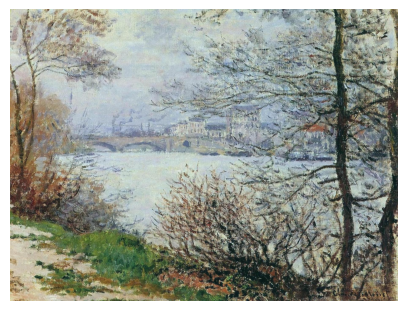

7. Painting ID: 29707, Score: 0.8360
   Title: Rough Sea
   Artist: Claude Monet
   Year Created: None
   Genre: marina
   Art Style: Impressionism
   Media: None
   Description Tags: Boats-And-Ships,Seas-And-Oceans,Vehicle,Ship,Watercraft,Frigate,Boat
   Fields: painting
   Art Movements: Impressionism
   Nationality: French
   Bio: Oscar-Claude Monet (/moʊˈneɪ/; French: [klod mɔnɛ]; 14 November 1840 – 5 December 1926) was a founder of French Impressionist painting, and the most consistent and prolific practitioner of the movement's philosophy of expressing one's perceptions before nature, especially as applied to plein air landscape painting. The term "Impressionism" is derived from the title of his painting Impression, soleil levant (Impression, Sunrise), which was exhibited in 1874 in the first of the independent exhibitions mounted by Monet and his associates as an alternative to the Salon de Paris.
 Monet's ambition of documenting the French countryside led him to adopt a method 

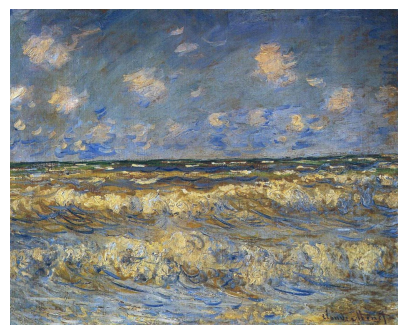

8. Painting ID: 29518, Score: 0.8309
   Title: Morning On The Seine 3
   Artist: Claude Monet
   Year Created: None
   Genre: None
   Art Style: Impressionism
   Media: None
   Description Tags: None
   Fields: painting
   Art Movements: Impressionism
   Nationality: French
   Bio: Oscar-Claude Monet (/moʊˈneɪ/; French: [klod mɔnɛ]; 14 November 1840 – 5 December 1926) was a founder of French Impressionist painting, and the most consistent and prolific practitioner of the movement's philosophy of expressing one's perceptions before nature, especially as applied to plein air landscape painting. The term "Impressionism" is derived from the title of his painting Impression, soleil levant (Impression, Sunrise), which was exhibited in 1874 in the first of the independent exhibitions mounted by Monet and his associates as an alternative to the Salon de Paris.
 Monet's ambition of documenting the French countryside led him to adopt a method of painting the same scene many times in order to cap

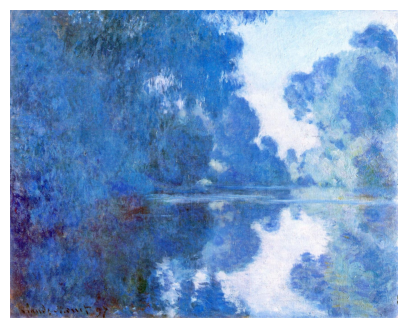

9. Painting ID: 30098, Score: 0.8308
   Title: The Seine At Vetheuil 3
   Artist: Claude Monet
   Year Created: None
   Genre: None
   Art Style: Impressionism
   Media: None
   Description Tags: None
   Fields: painting
   Art Movements: Impressionism
   Nationality: French
   Bio: Oscar-Claude Monet (/moʊˈneɪ/; French: [klod mɔnɛ]; 14 November 1840 – 5 December 1926) was a founder of French Impressionist painting, and the most consistent and prolific practitioner of the movement's philosophy of expressing one's perceptions before nature, especially as applied to plein air landscape painting. The term "Impressionism" is derived from the title of his painting Impression, soleil levant (Impression, Sunrise), which was exhibited in 1874 in the first of the independent exhibitions mounted by Monet and his associates as an alternative to the Salon de Paris.
 Monet's ambition of documenting the French countryside led him to adopt a method of painting the same scene many times in order to ca

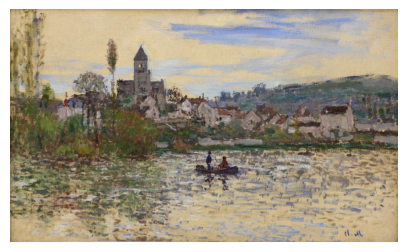

10. Painting ID: 30118, Score: 0.8292
   Title: The Small Arm Of The Seine At Argenteuil 1
   Artist: Claude Monet
   Year Created: None
   Genre: None
   Art Style: Impressionism
   Media: None
   Description Tags: None
   Fields: painting
   Art Movements: Impressionism
   Nationality: French
   Bio: Oscar-Claude Monet (/moʊˈneɪ/; French: [klod mɔnɛ]; 14 November 1840 – 5 December 1926) was a founder of French Impressionist painting, and the most consistent and prolific practitioner of the movement's philosophy of expressing one's perceptions before nature, especially as applied to plein air landscape painting. The term "Impressionism" is derived from the title of his painting Impression, soleil levant (Impression, Sunrise), which was exhibited in 1874 in the first of the independent exhibitions mounted by Monet and his associates as an alternative to the Salon de Paris.
 Monet's ambition of documenting the French countryside led him to adopt a method of painting the same scene many 

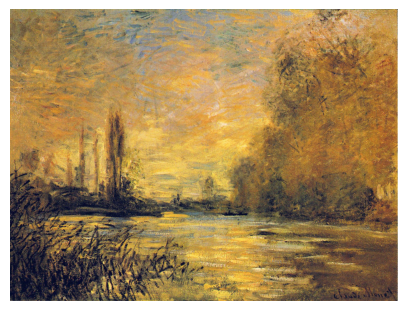

In [72]:
# Fetch the top painting metadata and image paths from the database
painting_ids = top_indices.tolist()
paintings = fetch_paintings(painting_ids)

for rank, painting in enumerate(paintings, start=1):
    print(f"{rank}. Painting ID: {painting['painting_id']}, Score: {scores[rank-1]:.4f}")
    print(f"   Title: {painting['title']}")
    print(f"   Artist: {painting['artist']}")
    print(f"   Year Created: {painting['year_created']}")
    print(f"   Genre: {painting['genre']}")
    print(f"   Art Style: {painting['art_style']}")
    print(f"   Media: {painting['media']}")
    print(f"   Description Tags: {painting['description_tags']}")
    print(f"   Fields: {painting['fields']}")
    print(f"   Art Movements: {painting['art_movements']}")
    print(f"   Nationality: {painting['nationality']}")
    print(f"   Bio: {painting['bio']}")
    print(f"   Image Path: {painting['image_path']}")

    image_path = painting.get('image_path')
    if image_path:
        image_path = (dataset_path / image_path).resolve()
        image = cv2.imread(str(image_path))
        if image is not None:
            image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
            plt.figure(figsize=(5, 5))
            plt.imshow(image_rgb)
            plt.axis('off')
            plt.show()
        else:
            print(f"Unable to load image from path: {image_path}")
    else:
        print("No image_path available for this painting.")

#### Per-Field Contribution Analysis

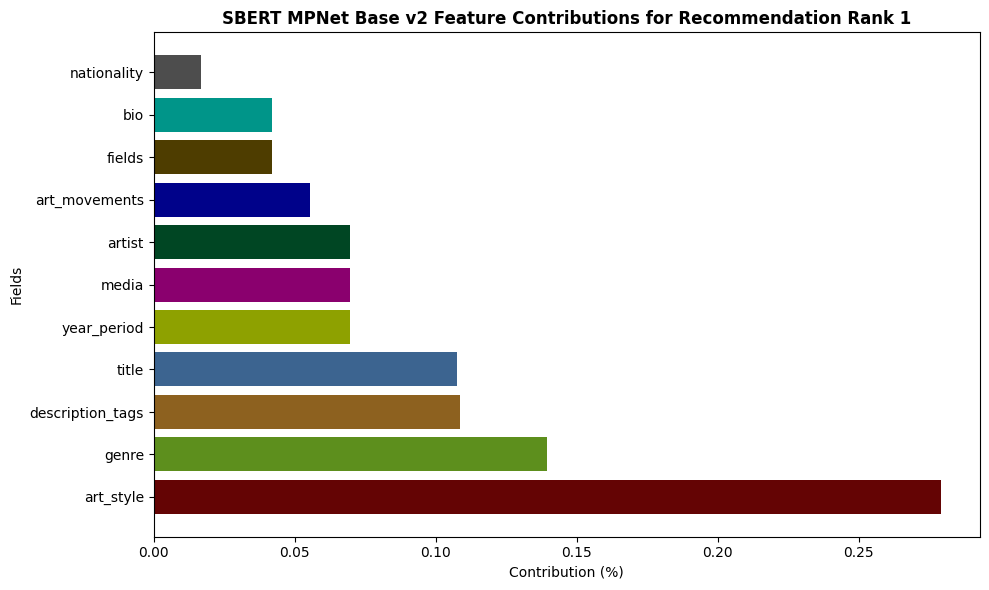

In [ ]:
def compute_feature_contributions(similarities, weights, retrieved_doc_idx):
    contributions = {}
    total = 0

    for field in similarities:
        value = weights[field] * similarities[field][retrieved_doc_idx]
        contributions[field] = value
        total += value

    # Normalise to percentages
    normalised = {
        field: (value / total if total != 0 else 0)
        for field, value in contributions.items()
    }

    return contributions, normalised, total

colors = ["#640404", "#5D8F1D", "#8D611F", "#3C6490",
          "#8EA100", "#8A006E", "#004623", "#00028A", "#4E3D00", "#009589", "#4D4D4D"]

# Compute contributions
retrieved_doc_index = top_indices[1]
contribs, norm_contribs, total = compute_feature_contributions(similarities, WEIGHTS, retrieved_doc_index)
sorted_items = sorted(norm_contribs.items(), key=lambda x: x[1], reverse=True)

labels = [k.replace('_missing', '') for k, _ in sorted_items]
values = [v for _, v in sorted_items]

# Plot bar chart
plt.figure(figsize=(10, 6))
plt.barh(labels, values, color=colors)

plt.title("SBERT MPNet Base v2 Feature Contributions for Recommendation Rank 1", fontweight='bold')
plt.xlabel("Contribution (%)")
plt.ylabel("Fields")

plt.tight_layout()
plt.show()

### Visualise Embedding Space

In [85]:
X = embedding_matrices["year_period"] 

umap_dim_red = umap.UMAP(n_neighbors=30, min_dist=0.1, metric='cosine', random_state=42)
emb_2d = umap_dim_red.fit_transform(X)

C:\Users\danie\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


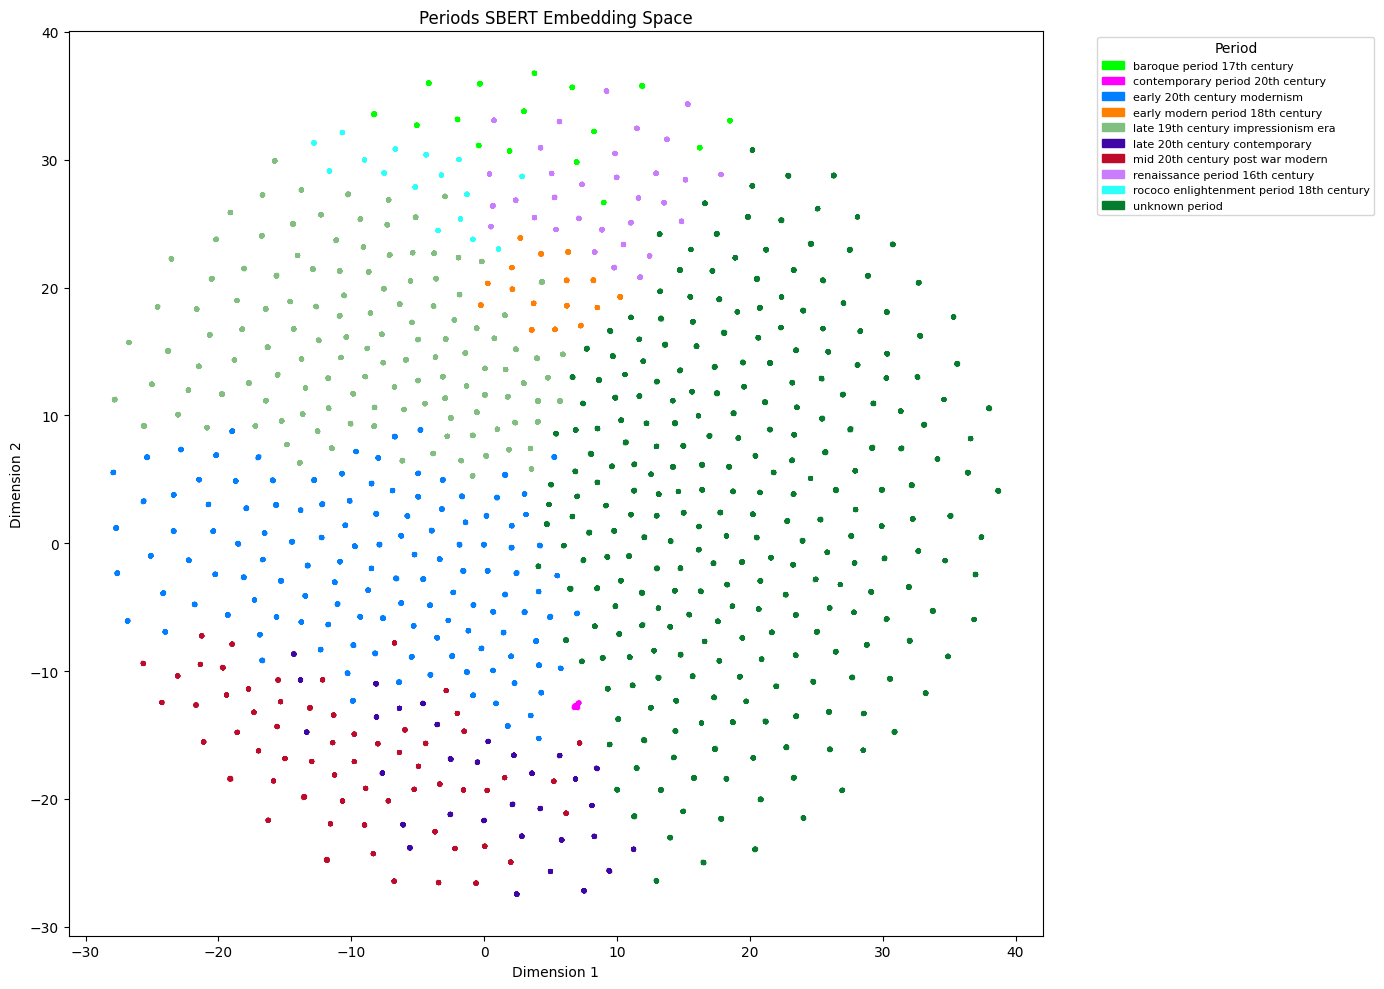

In [87]:
labels = []

for item_json, _ in processed_data:
    item = json.loads(item_json)

    labels.append(item["year_period"])

encoder = LabelEncoder()
label_ids = encoder.fit_transform(labels)

def distinct_cmap(n=35):
    hues = np.linspace(0, 1, n, endpoint=False)
    return [
        mcolors.hsv_to_rgb((h, 0.75, 0.95))
        for h in hues
    ]

#colors = distinct_cmap(len(encoder.classes_))
colors = distinctipy.get_colors(len(encoder.classes_))

plt.figure(figsize=(14, 10))

point_colors = [colors[i] for i in label_ids]

scatter = plt.scatter(
    emb_2d[:, 0],
    emb_2d[:, 1],
    c=point_colors,
    s=6,
    alpha=0.2
)


# legend
legend_handles = [
    mpatches.Patch(color=colors[i], label=label)
    for i, label in enumerate(encoder.classes_)
]

plt.legend(
    handles=legend_handles,
    title="Period",
    bbox_to_anchor=(1.05, 1),
    loc='upper left',
    fontsize=8
)

plt.title("Periods SBERT Embedding Space")
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")

plt.tight_layout()
plt.show()

In [ ]:
def build_combined_embeddings(embedding_matrices, weights):
    combined = None

    for field, matrix in embedding_matrices.items():
        weighted = matrix * weights[field]

        if combined is None:
            combined = weighted
        else:
            combined += weighted

    return combined

combined_embeddings = build_combined_embeddings(
    embedding_matrices,
    WEIGHTS
)

emb_2d = umap.UMAP(
    n_neighbors=30,
    min_dist=0.1,
    metric='cosine',
    random_state=42
).fit_transform(combined_embeddings)

In [ ]:
encoder = LabelEncoder()
label_ids = encoder.fit_transform(labels)

def distinct_cmap(n=35):
    hues = np.linspace(0, 1, n, endpoint=False)
    return [
        mcolors.hsv_to_rgb((h, 0.75, 0.95))
        for h in hues
    ]

#colors = distinct_cmap(len(encoder.classes_))
colors = distinctipy.get_colors(len(encoder.classes_))

plt.figure(figsize=(14, 10))

point_colors = [colors[i] for i in label_ids]
plt.scatter(
    emb_2d[:, 0],
    emb_2d[:, 1],
    c=point_colors,
    s=10,
    alpha=0.3
)

# legend
legend_handles = [
    mpatches.Patch(color=colors[i], label=label)
    for i, label in enumerate(encoder.classes_)
]

plt.legend(
    handles=legend_handles,
    title="Art Styles",
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
    fontsize=8
)

plt.title("Art Style SBERT Embedding Space")
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")

plt.tight_layout()
plt.show()

In [53]:
print(len(np.unique(combined_embeddings, axis=0)))

78321


# Evaluation 

**Predictive Quality Metrics**; Precision@k

**Ranking Quality Metrics**; MRR, MAP, NDCG, Hit Rate

**Behavioural Metrics**; Diversity, Novelty, Serendipity, Popularity bias 

https://www.evidentlyai.com/ranking-metrics/evaluating-recommender-systems#map

In [5]:
# Database connection
def get_db_connection():
    conn = psycopg2.connect(
        host="localhost",
        database="Evaluation_DB",
        user="postgres",
        password="Catmelon304!"
    )
    return conn

print(get_db_connection())

<connection object at 0x0000019B4663F450; dsn: 'user=postgres password=xxx dbname=Evaluation_DB host=localhost', closed: 0>


### Predictive and Ranking Quality Metrics
Such metrics reflect the “correctness” of recommendations and show how well the system finds relevant items

#### Precision@k, nDCG@k, mAP@k, MRR@k, HitRate@k

In [ ]:
# Metrics for one user and one set of recommendations + interactions
def metrics_one_one(user_id, request_id):
    conn = get_db_connection()
    cur = conn.cursor()

    # Get recommendations 
    cur.execute("""
        SELECT painting_id, rank
        FROM recommendations_sbert
        WHERE user_id = %s AND request_id = %s
        ORDER BY rank ASC
        LIMIT 20
    """, (user_id, request_id))

    recs = cur.fetchall()

    # Enforce minimum size requirement
    if len(recs) < 20:
        conn.close()
        return None  

    recommended_ids = [r[0] for r in recs]

    # Get relevant interactions for same request
    cur.execute("""
        SELECT painting_id, favourite, rating, click, viewing_time_seconds, review
        FROM interaction_summary
        WHERE user_id = %s AND request_id = %s
    """, (user_id, request_id))

    interactions = cur.fetchall()

    relevant_ids = set()
    for row in interactions:
        pid, favourite, rating, click, viewing_time_seconds, review = row

        if (
            favourite is True or
            click is True or
            (rating is not None and rating >= 4) or
            (viewing_time_seconds is not None and viewing_time_seconds>=3) or
            review is not None
        ):
            relevant_ids.add(pid)

    # Compute hits
    hits = sum(1 for pid in recommended_ids if pid in relevant_ids)
    precision = hits / 20.0
    hit_rate = 1.0 if hits > 0 else 0.0

    reciprocal_rank = 0.0

    for idx, pid in enumerate(recommended_ids):

        if pid in relevant_ids:
            reciprocal_rank = 1.0 / (idx + 1)
            break

    dcg = 0.0
    for idx, pid in enumerate(recommended_ids):

        if pid in relevant_ids:
            dcg += 1.0 / math.log2(idx + 2)

    ideal_hits = min(len(relevant_ids), 20)
    idcg = 0.0

    for i in range(ideal_hits):
        idcg += 1.0 / math.log2(i + 2)
    if idcg > 0:
        ndcg = dcg / idcg
    else:
        ndcg = 0.0

    ap_sum = 0.0
    hit_count = 0

    for idx, pid in enumerate(recommended_ids):
        if pid in relevant_ids:
            hit_count += 1
            precision_at_i = hit_count / (idx + 1)
            ap_sum += precision_at_i

    if len(relevant_ids) > 0:
        map_k = ap_sum / min(len(relevant_ids), 20)
    else:
        map_k = 0.0

    conn.close()

    return {
        "precision@20": precision,
        "ndcg@20": ndcg,
        "map@20": map_k,
        "hitrate@20": hit_rate,
        "mrr@20": reciprocal_rank,
        "relevant_items": len(relevant_ids)
    }

# Test for one user and one set of recommendations
metrics_one_one(11, "27bcc9d8-c5b0-47d8-a549-1a0230c0fef8")

{'precision@20': 0.15,
 'ndcg@20': 0.3809748461933143,
 'map@20': 0.16278166278166278,
 'hitrate@20': 1.0,
 'mrr@20': 0.09090909090909091,
 'relevant_items': 3}

In [26]:
# Metrics for one user, over all sets of recommendation + interactions
def metrics_one_all(user_id):
    conn = get_db_connection()
    cur = conn.cursor()

    # Get valid request_ids (must have >= 20 recs)
    cur.execute("""
        SELECT request_id
        FROM recommendations_sbert
        WHERE user_id = %s and score > 0
        GROUP BY request_id
        HAVING COUNT(*) >= 20
    """, (user_id,))

    request_ids = [r[0] for r in cur.fetchall()]

    if len(request_ids) == 0:
        conn.close()
        return None

    precisions = []
    ndcgs = []
    maps = []
    hitrates = []
    mrrs = []

    for request_id in request_ids:

        # Top 20 recommendations for this request
        cur.execute("""
            SELECT painting_id
            FROM recommendations_sbert
            WHERE user_id = %s AND request_id = %s
            ORDER BY rank ASC
            LIMIT 20
        """, (user_id, request_id))

        recs = cur.fetchall()
        recommended_ids = [r[0] for r in recs]

        if len(recommended_ids) < 20:
            continue

        # Get relevant interactions for same request
        cur.execute("""
            SELECT painting_id, favourite, rating, click, viewing_time_seconds, review
            FROM interaction_summary
            WHERE user_id = %s AND request_id = %s
        """, (user_id, request_id))

        interactions = cur.fetchall()

        relevant_ids = set()
        for row in interactions:
            favourite, rating, click, viewing_time_seconds, review = row[1], row[2], row[3], row[4], row[5]

            if (
                favourite is True or
                click is True or
                (rating is not None and rating >= 4) or
                (viewing_time_seconds is not None and viewing_time_seconds>=3) or
                review is not None
            ):
                relevant_ids.add(row[0])

        # Compute precision for this request
        hits = sum(1 for pid in recommended_ids if pid in relevant_ids)
        precision = hits / 20.0

        hitrate = 1.0 if hits > 0 else 0.0

        reciprocal_rank = 0.0
        for idx, pid in enumerate(recommended_ids):

            if pid in relevant_ids:
                reciprocal_rank = 1.0 / (idx + 1)
                break

        dcg = 0.0
        for idx, pid in enumerate(recommended_ids):

            if pid in relevant_ids:
                dcg += 1.0 / math.log2(idx + 2)

        ideal_hits = min(len(relevant_ids), 20)
        idcg = 0.0
        for i in range(ideal_hits):
            idcg += 1.0 / math.log2(i + 2)
        if idcg > 0:
            ndcg = dcg / idcg
        else:
            ndcg = 0.0

        ap_sum = 0.0
        hit_count = 0
        for idx, pid in enumerate(recommended_ids):
            if pid in relevant_ids:
                hit_count += 1
                precision_at_i = hit_count / (idx + 1)
                ap_sum += precision_at_i
        if len(relevant_ids) > 0:
            map_k = ap_sum / min(len(relevant_ids), 20)
        else:
            map_k = 0.0

        precisions.append(precision)
        ndcgs.append(ndcg)
        maps.append(map_k)
        hitrates.append(hitrate)
        mrrs.append(reciprocal_rank)

    conn.close()

    if len(precisions) == 0:
        return None

    return {
        "precision@20": sum(precisions) / len(precisions),
        "ndcg@20": sum(ndcgs) / len(ndcgs),
        "map@20": sum(maps) / len(maps),
        "hitrate@20": sum(hitrates) / len(hitrates),
        "mrr@20": sum(mrrs) / len(mrrs),
        "number_of_recommendation_sets": len(precisions)
    }

metrics_one_all(11)

{'precision@20': 0.041666666666666664,
 'ndcg@20': 0.2042074531494154,
 'map@20': 0.10802312086109817,
 'hitrate@20': 0.5,
 'mrr@20': 0.12750758839639126,
 'number_of_recommendation_sets': 90}

In [27]:
# Metrics for all users over all sets of recommendations
def metrics_all_users():

    conn = get_db_connection()
    cur = conn.cursor()

    cur.execute("""
        SELECT DISTINCT user_id
        FROM recommendations_sbert
        ORDER BY user_id
    """)

    users = [row[0] for row in cur.fetchall()]
    conn.close()

    per_user_metrics = {}

    system_precisions = []
    system_ndcgs = []
    system_maps = []
    system_hitrates = []
    system_mrrs = []

    for user_id in users:
        metrics = metrics_one_all(user_id)

        if metrics is None:
            continue

        # Store per-user metrics
        per_user_metrics[user_id] = metrics

        # Accumulate system metrics
        system_precisions.append(metrics["precision@20"])
        system_ndcgs.append(metrics["ndcg@20"])
        system_maps.append(metrics["map@20"])
        system_hitrates.append(metrics["hitrate@20"])
        system_mrrs.append(metrics["mrr@20"])

    if len(system_precisions) == 0:
        return None

    results = {
        "system_metrics": {
            "precision@20":
                sum(system_precisions) / len(system_precisions),
            "ndcg@20":
                sum(system_ndcgs) / len(system_ndcgs),
            "map@20":
                sum(system_maps) / len(system_maps),
            "hitrate@20":
                sum(system_hitrates) / len(system_hitrates),
            "mrr@20":
                sum(system_mrrs) / len(system_mrrs)
        },
        "per_user_metrics": per_user_metrics
    }

    return results

results = metrics_all_users()

print("Metrics for all users and all recommendation batches per user: ", results["system_metrics"])
print("Metrics for each users and all recommendation batches per user:", results["per_user_metrics"])

Metrics for all users and all recommendation batches per user:  {'precision@20': 0.01769874519684044, 'ndcg@20': 0.09314431573260676, 'map@20': 0.0538323358848845, 'hitrate@20': 0.20926547850634264, 'mrr@20': 0.06440615126123633}
Metrics for each users and all recommendation batches per user: {11: {'precision@20': 0.041666666666666664, 'ndcg@20': 0.2042074531494154, 'map@20': 0.10802312086109817, 'hitrate@20': 0.5, 'mrr@20': 0.12750758839639126, 'number_of_recommendation_sets': 90}, 12: {'precision@20': 0.022727272727272728, 'ndcg@20': 0.12694222094330135, 'map@20': 0.08712121212121211, 'hitrate@20': 0.22727272727272727, 'mrr@20': 0.09848484848484848, 'number_of_recommendation_sets': 22}, 13: {'precision@20': 0.0035714285714285718, 'ndcg@20': 0.030762611290956646, 'map@20': 0.017857142857142856, 'hitrate@20': 0.07142857142857142, 'mrr@20': 0.017857142857142856, 'number_of_recommendation_sets': 14}, 16: {'precision@20': 0.058695652173913045, 'ndcg@20': 0.26814172231901867, 'map@20': 0.1

## Behavioural Metrics

#### Diversity 

Measures how similar the recommended items are to each other, thus Intra List Similarity (ILS), where low similarity indicates high diversity and high similarity indicates redundant recommendations due to high similarity.

For a recommendation list:

$$
R = \{ i_1, \dots, i_K \}
$$

the Intra-List Similarity (ILS) is defined as:

$$
ILS = \frac{2}{K(K - 1)} \sum_{a < b} \mathrm{sim}(i_a, i_b)
$$

where $\mathrm{sim}(i_a, i_b)$ is a similarity function between items $i_a$ and $i_b$.

Diversity is then defined as:

$$
Diversity = 1 - ILS
$$

In [79]:
def build_weighted_sbert_item_vectors(embedding_matrices, weights):
    """
    Converts multiple SBERT field embedding matrices into one item vector matrix.

    embedding_matrices:
        dict[field_name] = np.array of shape (num_items, embedding_dim)

    weights:
        dict[field_name] = float
    """

    weighted_matrices = []

    for field, matrix in embedding_matrices.items():
        weight = weights.get(field, 0.0)
        weighted_matrix = matrix * weight
        weighted_matrices.append(weighted_matrix)

    item_vectors = np.hstack(weighted_matrices)
    item_vectors = normalize(item_vectors, norm="l2")

    return item_vectors

sbert_item_vectors = build_weighted_sbert_item_vectors(embedding_matrices, WEIGHTS)

In [91]:
def compute_diversity(top_indices, item_vectors):
    vectors = item_vectors[top_indices]
    sim_matrix = cosine_similarity(vectors)
    k = len(top_indices)
    pairwise_sims = sim_matrix[np.triu_indices(k, k=1)]
    ils = np.mean(pairwise_sims) if len(pairwise_sims) > 0 else 0.0
    diversity = 1.0 - ils
    return diversity

In [47]:
def diversity_one_one(user_id, request_id, item_vectors, painting_id_to_index, k=20):
    conn = get_db_connection()
    cur = conn.cursor()

    cur.execute("""
        SELECT painting_id
        FROM recommendations_sbert
        WHERE user_id = %s
          AND request_id = %s
          AND score > 0
        ORDER BY rank ASC
        LIMIT %s
    """, (user_id, request_id, k))

    recs = cur.fetchall()

    cur.close()
    conn.close()

    if len(recs) < k:
        return None

    painting_ids = [row[0] for row in recs]

    top_indices = [
        painting_id_to_index[int(pid)]
        for pid in painting_ids
        if int(pid) in painting_id_to_index
    ]

    if len(top_indices) < k:
        return None

    diversity = compute_diversity(top_indices, item_vectors)

    return diversity

print(diversity_one_one(11, "27bcc9d8-c5b0-47d8-a549-1a0230c0fef8", sbert_item_vectors, painting_id_to_index, k=20))

0.6528856754302979


In [49]:
def diversity_one_all(user_id, item_vectors, painting_id_to_index, k=20):
    conn = get_db_connection()
    cur = conn.cursor()

    cur.execute("""
        SELECT request_id
        FROM recommendations_sbert
        WHERE user_id = %s
          AND score > 0
        GROUP BY request_id
        HAVING COUNT(*) >= %s
    """, (user_id, k))

    request_ids = [row[0] for row in cur.fetchall()]

    cur.close()
    conn.close()

    if len(request_ids) == 0:
        return None

    diversity_scores = []

    for request_id in request_ids:
        diversity = diversity_one_one(
            user_id,
            request_id,
            item_vectors,
            painting_id_to_index,
            k=k
        )

        if diversity is not None:
            diversity_scores.append(diversity)

    if len(diversity_scores) == 0:
        return None

    return sum(diversity_scores) / len(diversity_scores)

diversity_one_all(11, sbert_item_vectors, painting_id_to_index, k=20)

0.4683651758564843

In [50]:
def diversity_all_users(item_vectors, painting_id_to_index, k=20):
    conn = get_db_connection()
    cur = conn.cursor()

    cur.execute("""
        SELECT DISTINCT user_id
        FROM recommendations_sbert
        ORDER BY user_id
    """)

    users = [row[0] for row in cur.fetchall()]

    cur.close()
    conn.close()

    per_user_diversity = {}

    for user_id in users:
        diversity = diversity_one_all(
            user_id,
            item_vectors,
            painting_id_to_index,
            k=k
        )

        if diversity is not None:
            per_user_diversity[user_id] = diversity

    if len(per_user_diversity) == 0:
        return None

    system_diversity = (
        sum(per_user_diversity.values())
        / len(per_user_diversity)
    )

    return {
        "system_diversity@20": system_diversity,
        "per_user_diversity": per_user_diversity
    }

diversity_all_users(sbert_item_vectors, painting_id_to_index, k=20)

{'system_diversity@20': 0.4176352951826388,
 'per_user_diversity': {11: 0.4683651758564843,
  12: 0.47219904308969324,
  13: 0.46374242433479856,
  16: 0.2599231937657232,
  67: 0.18688756809002016,
  74: 0.5703044831752777,
  75: 0.5229611843824387,
  79: 0.5194317861910789,
  81: 0.43837572634220123,
  83: 0.37977975606918335,
  89: 0.3120179057121277}}

#### Novelty 
Novelty is inverse popularity, meaning it measures how uncommon/long-tail the recommendations are, where high novelty indicates rare items and low novely indicates popular items (also referred to as popularity bias). More on popularity bias will be discussed in further detail below. 

A typical formulation of item novelty is defined as:

$$
Novelty(i) = -\log_2 \left( \frac{popularity(i)}{N} \right)
$$

where $popularity(i)$ is the number of interactions (or popularity count) of item $i$, and $N$ is the total number of interactions in the dataset.

The overall novelty of a recommendation list $R$ is then computed by averaging over the top-$K$ recommended items:

For a recommendation list;

$$
R = \{ i_1, \dots, i_K \}
$$

$$
Novelty(R) = \frac{1}{K} \sum_{i \in R} Novelty(i)
$$


In [73]:
import json
import joblib
import numpy as np
from collections import Counter

processed_data = joblib.load("processed_data.pkl")

def load_processed_rows(processed_data):
    """
    Converts processed_data from:
        [(json_string, painting_id), ...]
    into:
        [{"painting_id": ..., "title": ..., "genre": ..., ...}, ...]
    """

    processed_rows = []

    for json_string, painting_id in processed_data:
        row = json.loads(json_string)
        row["painting_id"] = int(painting_id)
        processed_rows.append(row)

    return processed_rows

processed_rows = load_processed_rows(processed_data)

In [94]:
# Use different fields like genre, art_style, description_tags, etc.. 
def build_field_popularity(processed_rows):
    genre = Counter()
    art_style = Counter()
    description_tags = Counter()
    media = Counter()
    nationality = Counter()
    artist = Counter()
    fields = Counter()
    art_movements = Counter()

    for row in processed_rows:
        genre[row.get("genre", "")] += 1
        art_style[row.get("art_style", "")] += 1
        nationality[row.get("nationality", "")] += 1
        artist[row.get("artist", "")] += 1

        for tag in row.get("description_tags", []):
            if tag:
                description_tags[tag] += 1

        for art in row.get("art_movements", []):
            if art:
                art_movements[art] += 1

        for fie in row.get("fields", []):
            if fie:
                fields[fie] += 1

        for m in row.get("media", []):
            if m:
                media[m] += 1

    return {
        "genre": genre,
        "art_style": art_style,
        "art_movements": art_movements,
        "description_tags": description_tags,
        "media": media,
        "nationality": nationality,
        "artist": artist,
        "fields": fields,
    }

POPULARITY_WEIGHTS = {
    "genre": 0.20,
    "art_style": 0.20,
    "art_movements": 0.15,
    "description_tags": 0.15,
    "media": 0.10,
    "artist": 0.10,
    "nationality": 0.05,
    "fields": 0.05
}

def field_probability(field_pop, value, total_items):
    """
    Computes the popularity probability of a field value.
    For list-based fields, returns the mean probability across values.
    """

    if isinstance(value, list):
        values = [v for v in value if v]

        if len(values) == 0:
            return 1 / total_items

        return np.mean([
            field_pop.get(v, 1) / total_items
            for v in values
        ])

    if value is None or value == "":
        return 1 / total_items

    return field_pop.get(value, 1) / total_items

def compute_novelty(top_indices, processed_rows, field_popularity, total_items, weights):
    scores = []

    for idx in top_indices:
        row = processed_rows[idx]

        item_score = 0.0

        # Genre
        genre = row.get("genre", "")
        p = field_probability(field_popularity["genre"], genre, total_items)
        item_score += weights["genre"] * (-np.log2(p))

        # Art style
        style = row.get("art_style", "")
        p = field_probability(field_popularity["art_style"], style, total_items)
        item_score += weights["art_style"] * (-np.log2(p))

        # Art movements: already a list
        art_movements = row.get("art_movements", [])
        p = field_probability(field_popularity["art_movements"], art_movements, total_items)
        item_score += weights["art_movements"] * (-np.log2(p))

        # Description tags: already a list
        tags = row.get("description_tags", [])
        p = field_probability(field_popularity["description_tags"], tags, total_items)
        item_score += weights["description_tags"] * (-np.log2(p))

        # Media: already a list
        media = row.get("media", [])
        p = field_probability(field_popularity["media"], media, total_items)
        item_score += weights["media"] * (-np.log2(p))

        # Nationality
        nat = row.get("nationality", "")
        p = field_probability(field_popularity["nationality"], nat, total_items)
        item_score += weights["nationality"] * (-np.log2(p))

        # Artist
        artist = row.get("artist", "")
        p = field_probability(field_popularity["artist"], artist, total_items)
        item_score += weights["artist"] * (-np.log2(p))

        # Fields: already a list
        fields = row.get("fields", [])
        p = field_probability(field_popularity["fields"], fields, total_items)
        item_score += weights["fields"] * (-np.log2(p))

        scores.append(item_score)

    return np.mean(scores)

#### Serendipity 

Unexpectedness in contrast to ground truths (user interaction history)


In [6]:
def l2_normalise_matrix(matrix):
    matrix = matrix.astype(np.float32)
    return matrix / (np.linalg.norm(matrix, axis=1, keepdims=True) + 1e-8)


def build_sbert_embedding_lookup(painting_ids, embedding_matrices, field_weights):
    """
    Builds a painting_id -> weighted SBERT embedding lookup.

    embedding_matrices:
        Dictionary of field_name -> embedding matrix, where each matrix has shape (N, d).

    field_weights:
        Dictionary of field_name -> weight used during SBERT recommendation.

    painting_ids:
        List of painting IDs aligned with the row order of all embedding matrices.
    """

    fused_matrix = None
    total_weight = 0.0

    for field_name, matrix in embedding_matrices.items():

        if field_name not in field_weights:
            continue

        weight = float(field_weights[field_name])

        if weight == 0:
            continue

        matrix = l2_normalise_matrix(matrix)

        if fused_matrix is None:
            fused_matrix = weight * matrix
        else:
            fused_matrix += weight * matrix

        total_weight += weight

    if fused_matrix is None or total_weight == 0:
        raise ValueError("No valid SBERT fields were used to build the fused embedding matrix.")

    # Optional weighted average
    fused_matrix = fused_matrix / total_weight

    # Important: normalise after fusion so cosine similarity works correctly
    fused_matrix = l2_normalise_matrix(fused_matrix)

    embedding_lookup = {
        painting_id: fused_matrix[idx]
        for idx, painting_id in enumerate(painting_ids)
    }

    return embedding_lookup

def compute_unexpectedness(painting_id, user_history_ids, embedding_lookup):
    """
    Computes unexpectedness for an SBERT recommendation.

    unexpectedness = 1 - max cosine similarity between the recommended painting
    and the user's previous positively interacted paintings.
    """

    if painting_id not in embedding_lookup:
        return 0.0

    history_vectors = [
        embedding_lookup[hist_id]
        for hist_id in user_history_ids
        if hist_id in embedding_lookup and hist_id != painting_id
    ]

    if len(history_vectors) == 0:
        return 0.0

    recommended_vector = embedding_lookup[painting_id].reshape(1, -1)
    history_matrix = np.vstack(history_vectors)

    max_similarity = cosine_similarity(
        recommended_vector,
        history_matrix
    ).max()

    unexpectedness = 1.0 - max_similarity

    return max(0.0, unexpectedness)

In [7]:
def serendipity_all_users_all_recommendations_sbert(
    painting_ids,
    embedding_matrices,
    field_weights,
    top_k=20
):
    conn = get_db_connection()
    cur = conn.cursor()

    embedding_lookup = build_sbert_embedding_lookup(
        painting_ids=painting_ids,
        embedding_matrices=embedding_matrices,
        field_weights=field_weights
    )

    # Get all users that have valid SBERT recommendation requests
    cur.execute("""
        SELECT DISTINCT user_id
        FROM recommendations_sbert
        WHERE score > 0
    """)

    user_ids = [r[0] for r in cur.fetchall()]

    all_serendipities = []
    user_results = {}

    for user_id in user_ids:

        # Get valid request_ids for this user
        cur.execute("""
            SELECT request_id
            FROM recommendations_sbert
            WHERE user_id = %s AND score > 0
            GROUP BY request_id
            HAVING COUNT(*) >= %s
        """, (user_id, top_k))

        request_ids = [r[0] for r in cur.fetchall()]

        if len(request_ids) == 0:
            continue

        user_serendipities = []

        for request_id in request_ids:

            # Get top-K recommendations for this request
            cur.execute("""
                SELECT painting_id
                FROM recommendations_sbert
                WHERE user_id = %s AND request_id = %s AND score > 0
                ORDER BY rank ASC
                LIMIT %s
            """, (user_id, request_id, top_k))

            recs = cur.fetchall()
            recommended_ids = [r[0] for r in recs]

            if len(recommended_ids) < top_k:
                continue

            # Get relevant interactions for the same request
            cur.execute("""
                SELECT painting_id, favourite, rating, click, viewing_time_seconds, review
                FROM interaction_summary
                WHERE user_id = %s AND request_id = %s
            """, (user_id, request_id))

            interactions = cur.fetchall()

            relevant_ids = set()

            for row in interactions:
                painting_id = row[0]
                favourite = row[1]
                rating = row[2]
                click = row[3]
                viewing_time_seconds = row[4]
                review = row[5]

                if (
                    favourite is True or
                    click is True or
                    (rating is not None and rating >= 4) or
                    (viewing_time_seconds is not None and viewing_time_seconds >= 3) or
                    review is not None
                ):
                    relevant_ids.add(painting_id)

            # Get user's positive interaction history before or up to this request.
            # If you have timestamps, this can be made strictly previous-only.
            cur.execute("""
                SELECT DISTINCT painting_id
                FROM interaction_summary
                WHERE user_id = %s
                AND (
                    favourite = TRUE OR
                    click = TRUE OR
                    rating >= 4 OR
                    viewing_time_seconds >= 3 OR
                    review IS NOT NULL
                )
            """, (user_id,))

            history_rows = cur.fetchall()
            user_history_ids = set(r[0] for r in history_rows)

            # Avoid using the current recommendation list as its own history
            user_history_ids = user_history_ids - set(recommended_ids)

            serendipity_sum = 0.0

            for painting_id in recommended_ids:

                relevance = 1.0 if painting_id in relevant_ids else 0.0

                unexpectedness = compute_unexpectedness(
                    painting_id=painting_id,
                    user_history_ids=user_history_ids,
                    embedding_lookup=embedding_lookup
                )

                serendipity_sum += relevance * unexpectedness

            serendipity_at_k = serendipity_sum / top_k

            user_serendipities.append(serendipity_at_k)
            all_serendipities.append(serendipity_at_k)

        if len(user_serendipities) > 0:
            user_results[user_id] = {
                f"serendipity@{top_k}": sum(user_serendipities) / len(user_serendipities),
                "number_of_recommendation_sets": len(user_serendipities)
            }

    cur.close()
    conn.close()

    if len(all_serendipities) == 0:
        return None

    return {
        f"overall_serendipity@{top_k}": sum(all_serendipities) / len(all_serendipities),
        "number_of_users": len(user_results),
        "number_of_recommendation_sets": len(all_serendipities),
        "per_user_results": user_results
    }

In [11]:
ids = joblib.load("ids.pkl")
results = serendipity_all_users_all_recommendations_sbert(
    ids,
    embedding_matrices,
    WEIGHTS,
    top_k=20
)

print(results[f"overall_serendipity@20"])
print(results["number_of_users"])
print(results["number_of_recommendation_sets"])

0.002215938560538373
11
236


#### Popularity bias 

In the context of content-based recommendation systems, popularity bias emerges from frequent artsits, genres, etc... that dominate similarity resulting in a distribution skew, as seen in earlier plots for top k most frequent items per field. Unlike collaborative filtering, this system does not explicitly learn popularity, therefore frequency in the metadata space is what "popularity" is defined as in this system. The following metrics will be used to analyse popularity bias in the top-k recommendations per query.

**Average Recommendation Popularity (ARP)** is defined as follows;

$$
ARP= \frac{1}{∣R∣} ∑_{​i∈R} ​popularity(i)
$$

Where;

$R$ = recommended items, and

$popularity(i)$ = frequency or probability


In [93]:
def compute_item_popularity(idx, processed_rows, field_popularity, total_items, weights):
    """
    Computes weighted popularity score for one painting based on selected metadata fields.
    """

    row = processed_rows[idx]

    score = 0.0

    genre = row.get("genre", "")
    p = field_probability(field_popularity["genre"], genre, total_items)
    score += weights.get("genre", 0.0) * p

    art_style = row.get("art_style", "")
    p = field_probability(field_popularity["art_style"], art_style, total_items)
    score += weights.get("art_style", 0.0) * p

    art_movements = row.get("art_movements", [])
    p = field_probability(field_popularity["art_movements"], art_movements, total_items)
    score += weights.get("art_movements", 0.0) * p

    description_tags = row.get("description_tags", [])
    p = field_probability(field_popularity["description_tags"], description_tags, total_items)
    score += weights.get("description_tags", 0.0) * p

    media = row.get("media", [])
    p = field_probability(field_popularity["media"], media, total_items)
    score += weights.get("media", 0.0) * p

    nationality = row.get("nationality", "")
    p = field_probability(field_popularity["nationality"], nationality, total_items)
    score += weights.get("nationality", 0.0) * p

    artist = row.get("artist", "")
    p = field_probability(field_popularity["artist"], artist, total_items)
    score += weights.get("artist", 0.0) * p

    fields = row.get("fields", [])
    p = field_probability(field_popularity["fields"], fields, total_items)
    score += weights.get("fields", 0.0) * p

    return score

def compute_arp(top_indices, processed_rows, field_popularity, total_items, weights):
    """
    Computes Average Recommendation Popularity for one recommendation list.
    Higher values indicate more popular or common metadata values.
    """

    popularity_scores = []

    for idx in top_indices:
        popularity = compute_item_popularity(
            idx=idx,
            processed_rows=processed_rows,
            field_popularity=field_popularity,
            total_items=total_items,
            weights=weights
        )

        popularity_scores.append(popularity)

    return np.mean(popularity_scores)

**Coverage** is defined as follows;

$$
Coverage = \frac{\text{unique recommended items}}{\text{total dataset size}}
​$$

Low coverage indicates the same items are repeated, meaning the recommendations are highly biased, whereas high coverage indicates exploration and low bias.


In [99]:
def compute_coverage_from_counts(recommendation_counts):
    """
    Coverage = proportion of catalogue items recommended at least once.
    """
    return np.count_nonzero(recommendation_counts) / len(recommendation_counts)


**Gini Index** measures the inequality of recommendation distribution, where ≈0 indicates a fair distribution and ≈1 indicates only a few items dominate.

The Gini Coefficient formula is defined as follows;

$$
G = \frac{n + 1 - 2 \cdot \frac{\sum_{i=1}^{n} C_i}{C_n}}{n}
$$

Where;

$n$ = total number of items,

$f_i$ = frequency of item $i$ (after sorting in ascending order)

$C_i=∑_{j=1}^{i} f_j$ = cumulative frequency up to index $i$

$C_n=∑_{i=1}^{n} f_i$ = total frequency (normalization term)

In [100]:
def compute_gini_from_counts(recommendation_counts):
    """
    Gini Index over recommendation frequency distribution.
    Higher values indicate recommendations are concentrated on fewer paintings.
    """
    counts = np.asarray(recommendation_counts, dtype=np.float64)

    if counts.sum() == 0:
        return 0.0

    sorted_counts = np.sort(counts)
    n = len(sorted_counts)
    index = np.arange(1, n + 1)

    gini = np.sum((2 * index - n - 1) * sorted_counts) / (
        n * sorted_counts.sum()
    )

    return gini

### Behavioural Metric Results

In [101]:
import numpy as np
import time


def evaluation_sbert_batched(
    model,
    embedding_matrices,
    weights,
    item_vectors,
    painting_id_to_index,
    processed_rows,
    k=20,
    batch_size=128,
    print_every=25
):
    diversity_scores = []
    novelty_scores = []
    arp_scores = []

    total_items = len(processed_rows)
    recommendation_counts = np.zeros(total_items, dtype=np.float64)

    field_popularity_dict = build_field_popularity(processed_rows)

    novelty_field_weights = normalise_weights(POPULARITY_WEIGHTS)
    assert abs(sum(novelty_field_weights.values()) - 1) < 1e-6

    start_time = time.time()
    valid_queries = 0
    skipped_queries = 0

    print(f"Starting SBERT query simulation for {total_items} paintings...", flush=True)

    for batch_start in range(0, total_items, batch_size):
        batch_end = min(batch_start + batch_size, total_items)
        batch_rows = processed_rows[batch_start:batch_end]

        for local_idx, row in enumerate(batch_rows):
            global_idx = batch_start + local_idx

            query_clean = row
            painting_id = int(row["painting_id"])

            if painting_id not in painting_id_to_index:
                skipped_queries += 1
                continue

            top_indices, _, _ = recommend_sbert(
                query_structured=query_clean,
                model=model,
                embedding_matrices=embedding_matrices,
                weights=weights,
                painting_id_to_index=painting_id_to_index,
                query_id=painting_id,
                k=k
            )

            top_indices = np.asarray(top_indices, dtype=int)

            if len(top_indices) < k:
                skipped_queries += 1
                continue

            # Update counts directly for Coverage and Gini
            np.add.at(recommendation_counts, top_indices, 1)

            diversity = compute_diversity(
                top_indices=top_indices,
                item_vectors=item_vectors
            )
            diversity_scores.append(diversity)

            novelty = compute_novelty(
                top_indices=top_indices,
                processed_rows=processed_rows,
                field_popularity=field_popularity_dict,
                total_items=total_items,
                weights=novelty_field_weights
            )
            novelty_scores.append(novelty)

            arp = compute_arp(
                top_indices=top_indices,
                processed_rows=processed_rows,
                field_popularity=field_popularity_dict,
                total_items=total_items,
                weights=novelty_field_weights
            )
            arp_scores.append(arp)

            valid_queries += 1

            if valid_queries % print_every == 0:
                elapsed = time.time() - start_time
                processed = global_idx + 1
                avg_time = elapsed / processed
                remaining = avg_time * (total_items - processed)

                print(
                    f"Processed {processed}/{total_items} paintings | "
                    f"Valid queries: {valid_queries} | "
                    f"Skipped: {skipped_queries} | "
                    f"Avg time/query: {avg_time:.4f}s | "
                    f"Estimated remaining: {remaining / 60:.2f} min | "
                    f"Last Painting ID: {painting_id} | "
                    f"Diversity: {diversity:.4f}, "
                    f"Novelty: {novelty:.4f}, "
                    f"ARP: {arp:.6f}",
                    flush=True
                )

        elapsed = time.time() - start_time
        processed = batch_end
        avg_time = elapsed / processed
        remaining = avg_time * (total_items - processed)

        print(
            f"Finished batch {batch_start // batch_size + 1} | "
            f"Processed {processed}/{total_items} | "
            f"Estimated remaining: {remaining / 60:.2f} min",
            flush=True
        )

    if len(diversity_scores) == 0:
        return None

    coverage = compute_coverage_from_counts(recommendation_counts)
    gini = compute_gini_from_counts(recommendation_counts)

    total_time = time.time() - start_time

    return {
        "diversity": float(np.mean(diversity_scores)),
        "diversity_scores": diversity_scores,
        "novelty": float(np.mean(novelty_scores)),
        "novelty_scores": novelty_scores,
        "arp": float(np.mean(arp_scores)),
        "arp_scores": arp_scores,
        "coverage": float(coverage),
        "gini": float(gini),
        "number_of_queries": valid_queries,
        "skipped_queries": skipped_queries,
        "total_time_seconds": total_time,
        "avg_time_per_query": total_time / max(valid_queries, 1),
        "recommendation_counts": recommendation_counts
    }

In [102]:
painting_id_to_index = {
    row["painting_id"]: idx
    for idx, row in enumerate(processed_rows)
}

results = evaluation_sbert_batched(
    model=model,
    embedding_matrices=embedding_matrices,
    weights=WEIGHTS,
    item_vectors=sbert_item_vectors,
    painting_id_to_index=painting_id_to_index,
    processed_rows=processed_rows,
    k=20,
    batch_size=128,
    print_every=25
)

Starting SBERT query simulation for 81444 paintings...
Processed 25/81444 paintings | Valid queries: 25 | Skipped: 0 | Avg time/query: 0.3029s | Estimated remaining: 411.03 min | Last Painting ID: 25 | Diversity: 0.1356, Novelty: 3.5840, ARP: 0.229206
Processed 50/81444 paintings | Valid queries: 50 | Skipped: 0 | Avg time/query: 0.2964s | Estimated remaining: 402.08 min | Last Painting ID: 50 | Diversity: 0.0261, Novelty: 4.4765, ARP: 0.245337
Processed 75/81444 paintings | Valid queries: 75 | Skipped: 0 | Avg time/query: 0.2950s | Estimated remaining: 400.00 min | Last Painting ID: 75 | Diversity: 0.1121, Novelty: 3.4601, ARP: 0.264819
Processed 100/81444 paintings | Valid queries: 100 | Skipped: 0 | Avg time/query: 0.2967s | Estimated remaining: 402.22 min | Last Painting ID: 100 | Diversity: 0.1801, Novelty: 4.2751, ARP: 0.166717
Processed 125/81444 paintings | Valid queries: 125 | Skipped: 0 | Avg time/query: 0.2955s | Estimated remaining: 400.55 min | Last Painting ID: 125 | Dive

In [103]:
# Average diversity, novelty, and arp over all top-k recommended items per query 
# as well as coverage and gini index
diversity_score = results["diversity"]
novelty_score = results["novelty"]
arp_score = results["arp"]
diversity_scores = results["diversity"]
novelty_scores = results["novelty"]
arp_scores = results["arp"]
coverage = results["coverage"]
gini = results["gini"] 

joblib.dump(diversity_scores, "mpnet_diversity.pkl")
joblib.dump(novelty_scores, "mpnet_novelty.pkl")

print(f"Diversity: {diversity_score:.4f}")
print(f"Novelty: {novelty_score:.4f}")
print(f"ARP: {arp_score:.4f}")
print(f"Coverage: {coverage:.4f}")
print(f"Gini Index: {gini:.4f}")

Diversity: 0.1306
Novelty: 3.9270
ARP: 0.1797
Coverage: 0.9953
Gini Index: 0.3378


### Multilingual 

In [104]:
# Load SBERT model to be used for per-field embedding extraction 
model = SentenceTransformer('paraphrase-multilingual-mpnet-base-v2') # all-roberta-large-v1, paraphrase-multilingual-mpnet-base-v2, all-mpnet-base-v2

def prepare_field_text(value):
    if isinstance(value, list):
        return " | ".join(value) if value else ""
    text = str(value).strip()
    return text

In [105]:
embeddings = joblib.load("SBERT_embeddings_per_field_multilingual.pkl")

In [106]:
FIELDS = [
    "title", 
    "year_period", 
    "genre", 
    "art_style",
    "description_tags", 
    "media", 
    "artist",
    "nationality", 
    "fields", 
    "art_movements", 
    "bio"
]

def build_embedding_matrices(embeddings):
    embedding_matrices = {}
    for field in FIELDS:
        vectors = []

        all_vecs = [item[field] for item in embeddings if field in item]
        mean_vec = np.mean(all_vecs, axis=0)

        for item in embeddings:
            vec = item.get(field)
            
            if vec is None:
                vec = item.get(field, mean_vec) # fallback, since zero will create 0 similarity score when using cosine similarity
            vectors.append(vec)

        embedding_matrices[field] = np.vstack(vectors)  # shape: (N, 768)
    return embedding_matrices

embedding_matrices = build_embedding_matrices(embeddings)

In [107]:
painting_id_to_index = {
    row["painting_id"]: idx
    for idx, row in enumerate(processed_rows)
}

results = evaluation_sbert_batched(
    model=model,
    embedding_matrices=embedding_matrices,
    weights=WEIGHTS,
    item_vectors=sbert_item_vectors,
    painting_id_to_index=painting_id_to_index,
    processed_rows=processed_rows,
    k=20,
    batch_size=128,
    print_every=25
)

Starting SBERT query simulation for 81444 paintings...
Processed 25/81444 paintings | Valid queries: 25 | Skipped: 0 | Avg time/query: 0.2321s | Estimated remaining: 314.92 min | Last Painting ID: 25 | Diversity: 0.1365, Novelty: 3.5840, ARP: 0.229206
Processed 50/81444 paintings | Valid queries: 50 | Skipped: 0 | Avg time/query: 0.2272s | Estimated remaining: 308.21 min | Last Painting ID: 50 | Diversity: 0.0325, Novelty: 4.4458, ARP: 0.245342
Processed 75/81444 paintings | Valid queries: 75 | Skipped: 0 | Avg time/query: 0.2294s | Estimated remaining: 311.09 min | Last Painting ID: 75 | Diversity: 0.1296, Novelty: 3.4660, ARP: 0.255078
Processed 100/81444 paintings | Valid queries: 100 | Skipped: 0 | Avg time/query: 0.2299s | Estimated remaining: 311.72 min | Last Painting ID: 100 | Diversity: 0.1796, Novelty: 4.2415, ARP: 0.166584
Processed 125/81444 paintings | Valid queries: 125 | Skipped: 0 | Avg time/query: 0.2291s | Estimated remaining: 310.55 min | Last Painting ID: 125 | Dive

In [108]:
# Average diversity, novelty, and arp over all top-k recommended items per query 
# as well as coverage and gini index
diversity_score = results["diversity"]
novelty_score = results["novelty"]
arp_score = results["arp"]
diversity_scores = results["diversity"]
novelty_scores = results["novelty"]
arp_scores = results["arp"]
coverage = results["coverage"]
gini = results["gini"] 

joblib.dump(diversity_scores, "multi_diversity.pkl")
joblib.dump(novelty_scores, "multi_novelty.pkl")

print(f"Diversity: {diversity_score:.4f}")
print(f"Novelty: {novelty_score:.4f}")
print(f"ARP: {arp_score:.4f}")
print(f"Coverage: {coverage:.4f}")
print(f"Gini Index: {gini:.4f}")

Diversity: 0.1353
Novelty: 3.9334
ARP: 0.1790
Coverage: 0.9956
Gini Index: 0.3335


### RoBERTa

In [109]:
# Load SBERT model to be used for per-field embedding extraction 
model = SentenceTransformer('all-roberta-large-v1') # all-roberta-large-v1, paraphrase-multilingual-mpnet-base-v2, all-mpnet-base-v2

def prepare_field_text(value):
    if isinstance(value, list):
        return " | ".join(value) if value else ""
    text = str(value).strip()
    return text

In [110]:
embeddings = joblib.load("SBERT_embeddings_per_field_roberta.pkl")

In [111]:
FIELDS = [
    "title", 
    "year_period", 
    "genre", 
    "art_style",
    "description_tags", 
    "media", 
    "artist",
    "nationality", 
    "fields", 
    "art_movements", 
    "bio"
]

def build_embedding_matrices(embeddings):
    embedding_matrices = {}
    for field in FIELDS:
        vectors = []

        all_vecs = [item[field] for item in embeddings if field in item]
        mean_vec = np.mean(all_vecs, axis=0)

        for item in embeddings:
            vec = item.get(field)
            
            if vec is None:
                vec = item.get(field, mean_vec) # fallback, since zero will create 0 similarity score when using cosine similarity
            vectors.append(vec)

        embedding_matrices[field] = np.vstack(vectors)  # shape: (N, 768)
    return embedding_matrices

embedding_matrices = build_embedding_matrices(embeddings)

In [112]:
painting_id_to_index = {
    row["painting_id"]: idx
    for idx, row in enumerate(processed_rows)
}

results = evaluation_sbert_batched(
    model=model,
    embedding_matrices=embedding_matrices,
    weights=WEIGHTS,
    item_vectors=sbert_item_vectors,
    painting_id_to_index=painting_id_to_index,
    processed_rows=processed_rows,
    k=20,
    batch_size=128,
    print_every=25
)

Starting SBERT query simulation for 81444 paintings...
Processed 25/81444 paintings | Valid queries: 25 | Skipped: 0 | Avg time/query: 0.4074s | Estimated remaining: 552.90 min | Last Painting ID: 25 | Diversity: 0.1474, Novelty: 3.6204, ARP: 0.231118
Processed 50/81444 paintings | Valid queries: 50 | Skipped: 0 | Avg time/query: 0.3961s | Estimated remaining: 537.32 min | Last Painting ID: 50 | Diversity: 0.0325, Novelty: 4.4458, ARP: 0.245342
Processed 75/81444 paintings | Valid queries: 75 | Skipped: 0 | Avg time/query: 0.3930s | Estimated remaining: 532.96 min | Last Painting ID: 75 | Diversity: 0.1141, Novelty: 3.4720, ARP: 0.263187
Processed 100/81444 paintings | Valid queries: 100 | Skipped: 0 | Avg time/query: 0.3906s | Estimated remaining: 529.54 min | Last Painting ID: 100 | Diversity: 0.1695, Novelty: 4.1838, ARP: 0.174305
Processed 125/81444 paintings | Valid queries: 125 | Skipped: 0 | Avg time/query: 0.3885s | Estimated remaining: 526.50 min | Last Painting ID: 125 | Dive

In [113]:
# Average diversity, novelty, and arp over all top-k recommended items per query 
# as well as coverage and gini index
diversity_score = results["diversity"]
novelty_score = results["novelty"]
arp_score = results["arp"]
diversity_scores = results["diversity"]
novelty_scores = results["novelty"]
arp_scores = results["arp"]
coverage = results["coverage"]
gini = results["gini"] 

joblib.dump(diversity_scores, "roberta_diversity.pkl")
joblib.dump(novelty_scores, "roberta_novelty.pkl")

print(f"Diversity: {diversity_score:.4f}")
print(f"Novelty: {novelty_score:.4f}")
print(f"ARP: {arp_score:.4f}")
print(f"Coverage: {coverage:.4f}")
print(f"Gini Index: {gini:.4f}")

Diversity: 0.1338
Novelty: 3.9263
ARP: 0.1794
Coverage: 0.9950
Gini Index: 0.3395
